In [1]:
# ============================================================
# Evaluate trained DeepONet
#
# Metrics on DENORMALIZED PA:
#   MSE
#   MAE
#   RMSE
#   Relative L2
#   R2
#
# Outputs:
#   quantitative_metrics.txt
#   per_sample_metrics.csv
# ============================================================

import os
import glob
import csv
import random

import numpy as np
import h5py

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. Configuration
# ============================================================

# Original dataset
DATA_ROOT = "Training dataset"

# ------------------------------------------------------------
# CHANGE THIS:
# folder containing:
#   best_deeponet.pt
#   normalization_parameters.npz
# ------------------------------------------------------------
RUN_DIR = os.path.join(
    "deeponet_mat_dataset_results",
    "run_20260825_130635"
)

MODEL_PATH = os.path.join(
    RUN_DIR,
    "best_deeponet.pt"
)

NORM_PATH = os.path.join(
    RUN_DIR,
    "normalization_parameters.npz"
)

OUTPUT_TXT = os.path.join(
    RUN_DIR,
    "quantitative_metrics.txt"
)

OUTPUT_CSV = os.path.join(
    RUN_DIR,
    "per_sample_metrics.csv"
)


# ============================================================
# Dataset configuration
# ============================================================

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

SEED = 42

NT = 501
NX = 200

LATENT_DIM = 128
TRUNK_HIDDEN = 128

BATCH_SIZE = 1


# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", DEVICE)


# ============================================================
# 2. Random seed
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 3. Find original dataset
# ============================================================

all_files = glob.glob(
    os.path.join(
        DATA_ROOT,
        "**",
        "*.mat"
    ),
    recursive=True
)

all_files = sorted(all_files)

print("\nTotal MAT files:", len(all_files))

if len(all_files) == 0:
    raise RuntimeError(
        f"No MAT files found in: {DATA_ROOT}"
    )


# ============================================================
# IMPORTANT:
# reproduce exactly the original random split
# ============================================================

random.shuffle(all_files)

n_total = len(all_files)

n_train = int(
    n_total * TRAIN_RATIO
)

n_val = int(
    n_total * VAL_RATIO
)

train_files = all_files[
    :n_train
]

val_files = all_files[
    n_train:
    n_train + n_val
]

test_files = all_files[
    n_train + n_val:
]


print("\nDataset split:")
print("Train:", len(train_files))
print("Val  :", len(val_files))
print("Test :", len(test_files))


# ============================================================
# 4. Load normalization parameters
# ============================================================

norm = np.load(NORM_PATH)

pt_mean = float(norm["pt_mean"])
pt_std = float(norm["pt_std"])

pa_mean = float(norm["pa_mean"])
pa_std = float(norm["pa_std"])


print("\nNormalization parameters:")

print(
    f"PT mean = {pt_mean:.6e}"
)

print(
    f"PT std  = {pt_std:.6e}"
)

print(
    f"PA mean = {pa_mean:.6e}"
)

print(
    f"PA std  = {pa_std:.6e}"
)


# ============================================================
# 5. Dataset
# ============================================================

class MatHeatAcousticDataset(Dataset):

    def __init__(
        self,
        file_list,
        pt_mean,
        pt_std,
        pa_mean,
        pa_std
    ):

        self.file_list = file_list

        self.pt_mean = pt_mean
        self.pt_std = pt_std

        self.pa_mean = pa_mean
        self.pa_std = pa_std


    def __len__(self):

        return len(
            self.file_list
        )


    def __getitem__(
        self,
        idx
    ):

        mat_path = self.file_list[
            idx
        ]


        with h5py.File(
            mat_path,
            "r"
        ) as f:

            PT = np.asarray(
                f["PT"],
                dtype=np.float32
            )

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )


        # ----------------------------------------------------
        # Shape check
        # ----------------------------------------------------

        if PT.shape != (NT, NX):

            raise ValueError(
                f"Wrong PT shape in {mat_path}: "
                f"{PT.shape}"
            )


        if PA.shape != (NT, NX):

            raise ValueError(
                f"Wrong PA shape in {mat_path}: "
                f"{PA.shape}"
            )


        # ----------------------------------------------------
        # Normalize
        # ----------------------------------------------------

        PT_norm = (
            PT
            -
            self.pt_mean
        ) / self.pt_std


        PA_norm = (
            PA
            -
            self.pa_mean
        ) / self.pa_std


        PT_norm = torch.tensor(
            PT_norm,
            dtype=torch.float32
        ).unsqueeze(0)


        PA_norm = torch.tensor(
            PA_norm,
            dtype=torch.float32
        ).unsqueeze(0)


        return (
            PT_norm,
            PA_norm,
            mat_path
        )


# ============================================================
# Test dataset
# ============================================================

test_dataset = MatHeatAcousticDataset(

    test_files,

    pt_mean,
    pt_std,

    pa_mean,
    pa_std
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


# ============================================================
# 6. Branch Net
# ============================================================

class BranchNet(nn.Module):

    def __init__(
        self,
        latent_dim=128
    ):

        super().__init__()


        self.encoder = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=5,
                stride=2,
                padding=2
            ),

            nn.BatchNorm2d(32),

            nn.GELU(),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.GELU(),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.GELU(),


            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.GELU(),


            nn.Conv2d(
                256,
                256,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.GELU()
        )


        self.pool = nn.AdaptiveAvgPool2d(
            output_size=(4, 4)
        )


        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 4 * 4,
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.1
            ),

            nn.Linear(
                512,
                latent_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.encoder(x)

        x = self.pool(x)

        x = self.fc(x)

        return x


# ============================================================
# 7. Trunk Net
# ============================================================

class TrunkNet(nn.Module):

    def __init__(
        self,
        latent_dim=128,
        hidden_dim=128
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                2,
                hidden_dim
            ),

            nn.GELU(),


            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.GELU(),


            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.GELU(),


            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.GELU(),


            nn.Linear(
                hidden_dim,
                latent_dim
            )
        )


    def forward(
        self,
        coords
    ):

        return self.net(
            coords
        )


# ============================================================
# 8. DeepONet
# ============================================================

class DeepONet2D(nn.Module):

    def __init__(
        self,
        latent_dim=128,
        trunk_hidden=128,
        nt=501,
        nx=200
    ):

        super().__init__()


        self.latent_dim = latent_dim

        self.nt = nt
        self.nx = nx


        self.branch = BranchNet(
            latent_dim=latent_dim
        )


        self.trunk = TrunkNet(
            latent_dim=latent_dim,
            hidden_dim=trunk_hidden
        )


        self.bias = nn.Parameter(
            torch.zeros(1)
        )


        # ----------------------------------------------------
        # Coordinates
        # ----------------------------------------------------

        t = torch.linspace(
            -1.0,
            1.0,
            nt
        )

        x = torch.linspace(
            -1.0,
            1.0,
            nx
        )


        tt, xx = torch.meshgrid(

            t,
            x,

            indexing="ij"
        )


        coords = torch.stack(

            [
                tt,
                xx
            ],

            dim=-1
        )


        coords = coords.reshape(
            -1,
            2
        )


        self.register_buffer(
            "coords",
            coords
        )


    def forward(
        self,
        pt
    ):

        batch_size = pt.shape[0]


        branch_features = self.branch(
            pt
        )


        trunk_features = self.trunk(
            self.coords
        )


        output = torch.einsum(

            "bl,nl->bn",

            branch_features,

            trunk_features
        )


        output = (
            output
            /
            np.sqrt(
                self.latent_dim
            )
        )


        output = (
            output
            +
            self.bias
        )


        output = output.reshape(

            batch_size,

            1,

            self.nt,

            self.nx
        )


        return output


# ============================================================
# 9. Build model
# ============================================================

model = DeepONet2D(

    latent_dim=LATENT_DIM,

    trunk_hidden=TRUNK_HIDDEN,

    nt=NT,

    nx=NX

).to(
    DEVICE
)


# ============================================================
# 10. Load trained weights
# ============================================================

print("\nLoading trained model:")

print(MODEL_PATH)


state_dict = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=True
)


model.load_state_dict(
    state_dict
)


model.eval()


print("Model loaded successfully.")


# ============================================================
# 11. Metric functions
# ============================================================

def calculate_metrics(
    pred,
    target
):

    # --------------------------------------------------------
    # Flatten
    # --------------------------------------------------------

    pred = pred.reshape(-1).astype(
        np.float64
    )

    target = target.reshape(-1).astype(
        np.float64
    )


    error = pred - target


    # ========================================================
    # MSE
    # ========================================================

    mse = np.mean(
        error ** 2
    )


    # ========================================================
    # MAE
    # ========================================================

    mae = np.mean(
        np.abs(error)
    )


    # ========================================================
    # RMSE
    # ========================================================

    rmse = np.sqrt(
        mse
    )


    # ========================================================
    # Relative L2
    #
    # ||prediction - target||_2
    # ---------------------------
    #       ||target||_2
    # ========================================================

    rel_l2 = (
        np.linalg.norm(
            error
        )
        /
        (
            np.linalg.norm(
                target
            )
            +
            1e-12
        )
    )


    # ========================================================
    # R^2
    #
    # 1 - SSE / SST
    # ========================================================

    ss_res = np.sum(
        error ** 2
    )


    target_mean = np.mean(
        target
    )


    ss_tot = np.sum(
        (
            target
            -
            target_mean
        ) ** 2
    )


    r2 = (
        1.0
        -
        ss_res
        /
        (
            ss_tot
            +
            1e-12
        )
    )


    return (
        mse,
        mae,
        rmse,
        rel_l2,
        r2
    )


# ============================================================
# 12. Evaluate entire test set
# ============================================================

all_pred = []
all_true = []

per_sample_results = []


print("\nEvaluating test set...\n")


with torch.no_grad():

    for i, (
        PT_norm,
        PA_norm,
        file_path
    ) in enumerate(
        test_loader
    ):


        PT_norm = PT_norm.to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # Prediction
        # ====================================================

        pred_norm = model(
            PT_norm
        )


        pred_norm = (
            pred_norm
            .cpu()
            .numpy()
        )


        PA_norm_np = (
            PA_norm
            .numpy()
        )


        # ====================================================
        # DENORMALIZE
        #
        # This is important:
        # calculate metrics in real PA scale
        # ====================================================

        pred_real = (
            pred_norm
            *
            pa_std
            +
            pa_mean
        )


        PA_real = (
            PA_norm_np
            *
            pa_std
            +
            pa_mean
        )


        # ====================================================
        # Save for global metrics
        # ====================================================

        all_pred.append(
            pred_real.reshape(-1)
        )

        all_true.append(
            PA_real.reshape(-1)
        )


        # ====================================================
        # Per-sample metrics
        # ====================================================

        (
            mse,
            mae,
            rmse,
            rel_l2,
            r2

        ) = calculate_metrics(

            pred_real,

            PA_real
        )


        # DataLoader returns path as list/tuple
        if isinstance(
            file_path,
            (list, tuple)
        ):

            file_name = file_path[0]

        else:

            file_name = str(
                file_path
            )


        per_sample_results.append(

            [
                i + 1,
                file_name,
                mse,
                mae,
                rmse,
                rel_l2,
                r2
            ]
        )


        print(

            f"[{i + 1:03d}/{len(test_dataset):03d}] "

            f"MSE={mse:.6e} | "

            f"MAE={mae:.6e} | "

            f"RMSE={rmse:.6e} | "

            f"RelL2={rel_l2:.6e} | "

            f"R2={r2:.6f}"
        )


# ============================================================
# 13. GLOBAL metrics
#
# concatenate ALL test pixels first,
# then calculate one global metric
#
# This is recommended for model comparison.
# ============================================================

all_pred = np.concatenate(
    all_pred
)

all_true = np.concatenate(
    all_true
)


(
    global_mse,
    global_mae,
    global_rmse,
    global_rel_l2,
    global_r2

) = calculate_metrics(

    all_pred,

    all_true
)


# ============================================================
# 14. Also calculate mean ± std across samples
# ============================================================

metric_array = np.asarray(

    [
        row[2:]
        for row in per_sample_results
    ],

    dtype=np.float64
)


sample_mean = np.mean(
    metric_array,
    axis=0
)


sample_std = np.std(
    metric_array,
    axis=0
)


# ============================================================
# 15. Print results
# ============================================================

print("\n")
print("=" * 72)

print(
    "FINAL QUANTITATIVE RESULTS"
)

print(
    "Metrics calculated on DENORMALIZED PA"
)

print("=" * 72)


print(
    f"MSE      : {global_mse:.8e}"
)

print(
    f"MAE      : {global_mae:.8e}"
)

print(
    f"RMSE     : {global_rmse:.8e}"
)

print(
    f"Rel. L2  : {global_rel_l2:.8e}"
)

print(
    f"R2       : {global_r2:.8f}"
)


print("-" * 72)

print(
    "Per-sample mean ± std:"
)

print(
    f"MSE      : "
    f"{sample_mean[0]:.8e} "
    f"± {sample_std[0]:.8e}"
)

print(
    f"MAE      : "
    f"{sample_mean[1]:.8e} "
    f"± {sample_std[1]:.8e}"
)

print(
    f"RMSE     : "
    f"{sample_mean[2]:.8e} "
    f"± {sample_std[2]:.8e}"
)

print(
    f"Rel. L2  : "
    f"{sample_mean[3]:.8e} "
    f"± {sample_std[3]:.8e}"
)

print(
    f"R2       : "
    f"{sample_mean[4]:.8f} "
    f"± {sample_std[4]:.8f}"
)

print("=" * 72)


# ============================================================
# 16. Save per-sample CSV
# ============================================================

with open(
    OUTPUT_CSV,
    "w",
    newline=""
) as f:

    writer = csv.writer(
        f
    )


    writer.writerow(
        [
            "sample",
            "file",
            "mse",
            "mae",
            "rmse",
            "relative_l2",
            "r2"
        ]
    )


    writer.writerows(
        per_sample_results
    )


# ============================================================
# 17. Save summary TXT
# ============================================================

with open(
    OUTPUT_TXT,
    "w"
) as f:

    f.write(
        "DeepONet Quantitative Evaluation\n"
    )

    f.write(
        "Metrics calculated on "
        "DENORMALIZED PA\n\n"
    )


    f.write(
        "Global test-set metrics\n"
    )

    f.write(
        "=======================\n"
    )


    f.write(
        f"MSE      : "
        f"{global_mse:.8e}\n"
    )

    f.write(
        f"MAE      : "
        f"{global_mae:.8e}\n"
    )

    f.write(
        f"RMSE     : "
        f"{global_rmse:.8e}\n"
    )

    f.write(
        f"Rel. L2  : "
        f"{global_rel_l2:.8e}\n"
    )

    f.write(
        f"R2       : "
        f"{global_r2:.8f}\n"
    )


    f.write(
        "\nPer-sample mean ± std\n"
    )

    f.write(
        "=====================\n"
    )


    metric_names = [
        "MSE",
        "MAE",
        "RMSE",
        "Rel. L2",
        "R2"
    ]


    for name, mean, std in zip(
        metric_names,
        sample_mean,
        sample_std
    ):

        f.write(

            f"{name:<8}: "
            f"{mean:.8e} "
            f"+/- "
            f"{std:.8e}\n"
        )


print(
    "\nSaved:"
)

print(
    OUTPUT_TXT
)

print(
    OUTPUT_CSV
)

print(
    "\nEvaluation complete."
)

Using device: cuda

Total MAT files: 800

Dataset split:
Train: 640
Val  : 80
Test : 80

Normalization parameters:
PT mean = 3.135567e+01
PT std  = 2.164740e+01
PA mean = -2.100887e+04
PA std  = 2.847824e+05

Loading trained model:
deeponet_mat_dataset_results/run_20260825_130635/best_deeponet.pt
Model loaded successfully.

Evaluating test set...

[001/080] MSE=3.490115e+08 | MAE=6.434375e+03 | RMSE=1.868185e+04 | RelL2=9.365545e-01 | R2=0.121236
[002/080] MSE=1.320724e+09 | MAE=2.308156e+04 | RMSE=3.634177e+04 | RelL2=8.535409e-01 | R2=0.266743
[003/080] MSE=4.032487e+07 | MAE=3.505717e+03 | RMSE=6.350187e+03 | RelL2=8.313262e-01 | R2=0.268213
[004/080] MSE=1.823619e+09 | MAE=2.513708e+04 | RMSE=4.270386e+04 | RelL2=3.677492e-01 | R2=0.863635
[005/080] MSE=2.476642e+08 | MAE=5.649538e+03 | RMSE=1.573735e+04 | RelL2=9.449668e-01 | R2=0.098673
[006/080] MSE=1.998633e+08 | MAE=5.825398e+03 | RMSE=1.413730e+04 | RelL2=8.904606e-01 | R2=0.194698
[007/080] MSE=8.733958e+08 | MAE=1.441917e+0

PT shape: (501, 200)
PA ground-truth shape: (501, 200)
Network input shape: torch.Size([1, 1, 501, 200])
Predicted PA shape: (501, 200)


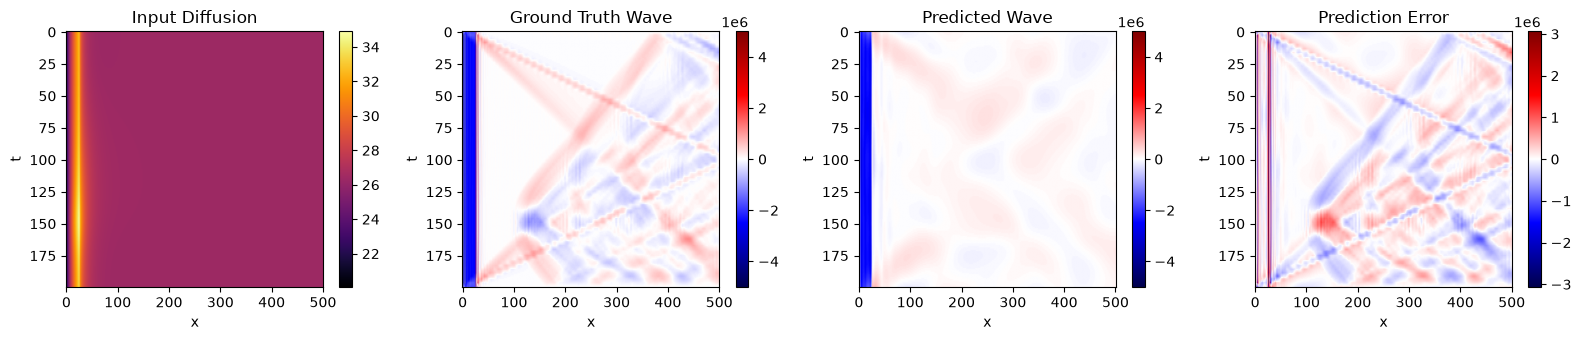

Figure saved to: deeponet_mat_dataset_results/run_20260825_130635/visualization_prediction/prediction_comparison.png


In [6]:
import os
import glob
import random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# Visualization prediction
# ============================================================

PREDICT_FILE = os.path.join(
    DATA_ROOT,
    "1",
    "Irregular_3_PT_0.5.mat"
)

OUT_DIR_VIS = os.path.join(
    RUN_DIR,
    "visualization_prediction"
)

os.makedirs(
    OUT_DIR_VIS,
    exist_ok=True
)


# ============================================================
# Load prediction sample
# ============================================================

def load_prediction_sample(mat_path):

    assert os.path.isfile(mat_path), (
        f"Prediction file not found: {mat_path}"
    )

    with h5py.File(
        mat_path,
        "r"
    ) as f:

        PT = np.asarray(
            f["PT"],
            dtype=np.float32
        )

        if "PA" in f:

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )

        else:

            PA = None


    assert PT.shape == (
        NT,
        NX
    ), (
        f"Wrong PT shape: {PT.shape}"
    )


    if PA is not None:

        assert PA.shape == (
            NT,
            NX
        ), (
            f"Wrong PA shape: {PA.shape}"
        )


    return PT, PA


# ============================================================
# Load data
# ============================================================

PT_real, PA_real = load_prediction_sample(
    PREDICT_FILE
)


print(
    "PT shape:",
    PT_real.shape
)


if PA_real is not None:

    print(
        "PA ground-truth shape:",
        PA_real.shape
    )

else:

    print(
        "No PA ground truth found in this file."
    )


# ============================================================
# Normalize input
# ============================================================

PT_norm = (

    PT_real
    -
    pt_mean

) / pt_std


PT_tensor = torch.tensor(

    PT_norm,

    dtype=torch.float32

).unsqueeze(
    0

).unsqueeze(
    0

).to(
    DEVICE
)


print(
    "Network input shape:",
    PT_tensor.shape
)


# ============================================================
# Prediction
# ============================================================

model.eval()


with torch.no_grad():

    PA_pred_norm = model(
        PT_tensor
    )


PA_pred_norm = (

    PA_pred_norm
    .cpu()
    .squeeze(0)
    .squeeze(0)
    .numpy()
)


# ============================================================
# Denormalize predicted PA
# ============================================================

PA_pred = (

    PA_pred_norm
    *
    pa_std
    +
    pa_mean
)


print(
    "Predicted PA shape:",
    PA_pred.shape
)


# ============================================================
# Visualization
# ============================================================

if PA_real is not None:


    error = (

        PA_pred
        -
        PA_real
    )


    # --------------------------------------------------------
    # Transpose for visualization
    #
    # [501, 200] -> [200, 501]
    # --------------------------------------------------------

    PT_plot = PT_real.T

    PA_real_plot = PA_real.T

    PA_pred_plot = PA_pred.T

    error_plot = error.T


    vmax = max(

        np.max(
            np.abs(
                PA_real_plot
            )
        ),

        np.max(
            np.abs(
                PA_pred_plot
            )
        )
    )


    evmax = np.max(
        np.abs(
            error_plot
        )
    )


    fig, axes = plt.subplots(

        1,

        4,

        figsize=(
            16,
            3.5
        )
    )


    # --------------------------------------------------------
    # Input PT
    # --------------------------------------------------------

    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    # --------------------------------------------------------
    # Ground truth PA
    # --------------------------------------------------------

    im1 = axes[1].imshow(

        PA_real_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Ground Truth Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    # --------------------------------------------------------
    # Predicted PA
    # --------------------------------------------------------

    im2 = axes[2].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[2].set_title(
        "Predicted Wave"
    )

    axes[2].set_xlabel(
        "x"
    )

    axes[2].set_ylabel(
        "t"
    )


    fig.colorbar(
        im2,
        ax=axes[2]
    )


    # --------------------------------------------------------
    # Error
    # --------------------------------------------------------

    im3 = axes[3].imshow(

        error_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-evmax,

        vmax=evmax
    )


    axes[3].set_title(
        "Prediction Error"
    )

    axes[3].set_xlabel(
        "x"
    )

    axes[3].set_ylabel(
        "t"
    )


    fig.colorbar(
        im3,
        ax=axes[3]
    )


    plt.tight_layout()


else:


    PT_plot = PT_real.T

    PA_pred_plot = PA_pred.T


    fig, axes = plt.subplots(

        1,

        2,

        figsize=(
            9,
            3.5
        )
    )


    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    vmax = np.max(
        np.abs(
            PA_pred_plot
        )
    )


    im1 = axes[1].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Predicted Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plot_path = os.path.join(

    OUT_DIR_VIS,

    "prediction_comparison.png"
)


plt.savefig(

    plot_path,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "Figure saved to:",
    plot_path
)